In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
#URL Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/lenna.jpg'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

In [5]:
#Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

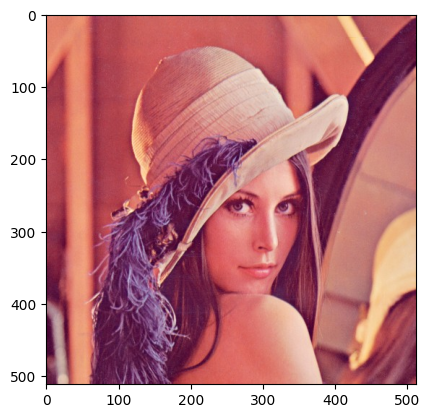

In [6]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [7]:
#Convert from RGB to Grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#### **Edge Detection Methods**

Edge detection is a fundamental tool in image processing and computer vision, used to identify points in a digital image where the image brightness changes sharply or has discontinuities. These discontinuities are typically organized into a set of curved line segments referred to as edges, which are crucial for feature extraction, image segmentation, and object recognition.

Here, we explore several common edge detection operators:

*   **Roberts Cross Operator:** The Roberts Cross operator is one of the simplest edge detection algorithms. It computes the sum of the squares of the differences between diagonally adjacent pixels. It's a 2x2 convolution kernel, sensitive to 45-degree and 135-degree diagonals, often resulting in noisy edges due to its small kernel size. The Kernels are:

```
Gx = [[1, 0], [0, -1]]
Gy = [[0, 1], [-1, 0]]
```

*   **Sobel Operator:** The Sobel operator is a more robust edge detection algorithm, utilizing a 3x3 convolution kernel to approximate the gradient of the image intensity. It smooths the image while calculating the gradient, making it less susceptible to noise than the Roberts operator. It's particularly good at detecting horizontal and vertical edges. The Kernels are:

```
Gx = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
Gy = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]
```

*   **Prewitt Operator:** Similar to the Sobel operator, the Prewitt operator also uses 3x3 convolution kernels to estimate the image gradient. However, unlike Sobel, it assigns equal weight to all pixels in the kernel, making it slightly simpler but potentially more sensitive to noise compared to Sobel. It also detects horizontal and vertical edges. The Kernels are:

```
Gx = [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]
Gy = [[-1, -1, -1], [0, 0, 0], [1, 1, 1]]
```

* **Canny Edge Detector:** The Canny edge detector is widely regarded as one of the optimal edge detection techniques due to its multi-stage algorithm designed to satisfy three main criteria: good detection (finds most real edges), good localization (edges are close to the real edges), and minimal response (only one response per edge). Its stages typically include:

  1.  **Noise Reduction**: Uses a Gaussian filter to smooth the image and remove noise.
  2.  **Gradient Calculation**: Finds the intensity gradients of the image.
  3.  **Non-maximum Suppression**: Thins the edges by preserving only local maxima in the gradient direction.
  4.  **Hysteresis Thresholding**: Applies two thresholds (high and low) to identify strong and weak edges, connecting weak edges only if they are connected to strong edges.

* **Laplacian Operator:** The Laplacian operator is a second-order derivative operator used to detect regions of rapid intensity change. It's rotationally invariant and detects edges in all directions. However, it's very sensitive to noise, as second derivatives amplify noise. It often highlights fine details and isolated points, making it useful for sharpening images. Example of a **3x3 Kernel**:

```
[[0, 1, 0], [1, -4, 1], [0, 1, 0]] or [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]
```





In [8]:
#Roberts
masc1 = np.array([[0, 1], [-1, 0]])
masc2 = np.array([[1, 0], [0, -1]])

img_roberts1 = cv2.filter2D(img_gray, -1, masc1)
img_roberts2 = cv2.filter2D(img_gray, -1, masc2)
img_roberts = cv2.add(img_roberts1, img_roberts2)

#Sobel
img_sobel1 = cv2.Sobel(img_gray,-1,1,0,ksize=3)
img_sobel2 = cv2.Sobel(img_gray,-1,0,1,ksize=3)
img_sobel = cv2.add(img_sobel1, img_sobel2)

#Prewitt
masc1 = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
masc2 = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

img_prewitt1 = cv2.filter2D(img_gray, -1, masc1)
img_prewitt2 = cv2.filter2D(img_gray, -1, masc2)
img_prewitt = cv2.add(img_prewitt1, img_prewitt2)

#Canny
img_canny = cv2.Canny(img_gray,100,200)

#Laplacian Edges
img_laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
img_laplacian = np.uint8(np.absolute(img_laplacian))

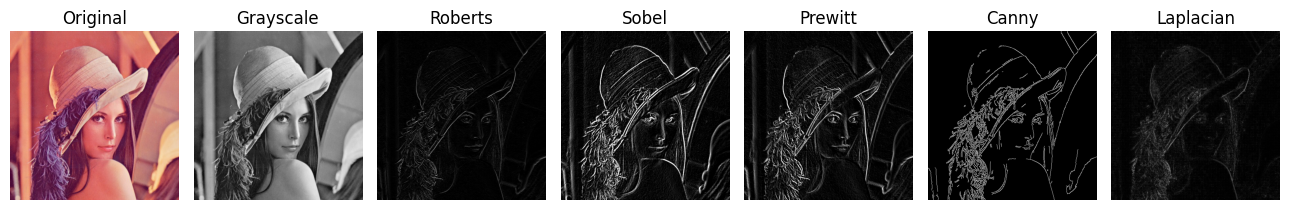

In [9]:
#Display all the Results
fig, axes = plot.subplots(1, 7, figsize=(13, 13))
axes = axes.flatten()

images = [img, img_gray, img_roberts, img_sobel, img_prewitt, img_canny, img_laplacian]
titles = ['Original', 'Grayscale', 'Roberts', 'Sobel', 'Prewitt', 'Canny', 'Laplacian']
cmaps = [None, 'gray', 'gray', 'gray', 'gray', 'gray', 'gray']

for i, (image, title, cmap) in enumerate(zip(images, titles, cmaps)):
    if i < len(axes):
        axes[i].imshow(image, cmap=cmap)
        axes[i].set_title(title)
        axes[i].axis('off')

for i in range(len(images), len(axes)):
    axes[i].axis('off')

plot.tight_layout()
plot.show()